# EDA

## Libs

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp, chi2_contingency

pd.set_option("display.max_columns", None)

## Data loading

In [2]:
os.getcwd()

'/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/notebooks'

In [3]:
file_path = '../data/Base.csv'

In [5]:
df = pd.read_csv(file_path)
df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,...,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,...,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,...,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,...,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7


In [14]:
df.columns

Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month'],
      dtype='object')

In [ ]:
TARGET = "fraud_bool"

SENTINEL_COLS = [
    "prev_address_months_count",
    "bank_months_count",
    "current_address_months_count",
    "session_length_in_minutes",
    "credit_risk_score",
    "device_distinct_emails_8w",
]

num_cols = df.select_dtypes("number").columns.drop(TARGET, errors="ignore")
cat_cols = df.select_dtypes(exclude="number").columns

# df_clean: -1 masked to NaN, for honest stats/plots
df_clean = df.copy()
df_clean[SENTINEL_COLS] = df_clean[SENTINEL_COLS].replace(-1, np.nan)

print(f"{len(num_cols)} numeric feature cols, {len(cat_cols)} categorical cols")
print("Categorical:", list(cat_cols))

26 numeric feature cols, 5 categorical cols
Categorical: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


## Base structure & data quality
Foundational pass — shape, dtypes, describe, duplicates, constant columns, skew, outliers — so the deeper analysis is trustworthy. Numeric stats use `df_clean` (the `-1` sentinels masked).

In [68]:
print(f"shape: {df.shape}")
df.info(show_counts=True)

shape: (1000000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h     

In [84]:
df.describe(include="all")

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AB,NaN,NaN,NaN,NaN,NaN,NaN,CA,NaN,NaN,BC,NaN,NaN,NaN,NaN,NaN,NaN,INTERNET,NaN,other,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,370554,NaN,NaN,NaN,NaN,NaN,NaN,730252,NaN,NaN,372143,NaN,NaN,NaN,NaN,NaN,NaN,992952,NaN,342728,NaN,NaN,NaN,NaN
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,NaN,1572.692049,5665.296605,4769.781965,4856.324016,184.361849,9.503544,NaN,130.989595,0.529886,NaN,0.417077,0.889676,10.839303,0.222988,515.851010,0.025242,NaN,7.544940,NaN,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,NaN,1005.374565,3009.380665,1479.212612,919.843934,459.625329,5.033792,NaN,69.681812,0.499106,NaN,0.493076,0.313293,12.116875,0.416251,487.559902,0.156859,NaN,8.033106,NaN,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,NaN,1.000000,-170.603072,1300.307314,2825.748405,0.000000,0.000000,NaN,-170.000000,0.000000,NaN,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,NaN,-1.000000,NaN,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,NaN,894.000000,3436.365848,3593.179135,4268.368423,1.000000,6.000000,NaN,83.000000,0.000000,NaN,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,NaN,3.103053,NaN,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,NaN,1263.000000,5319.769349,4749.921161,4913.436941,9.000000,9.000000,NaN,122.000000,1.000000,NaN,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,NaN,5.114321,NaN,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,NaN,1944.000000,7680.717827,5752.574191,5488.083356,25.000000,13.000000,NaN,178.000000,1.000000,NaN,1.000000,1.000000,25.000000,0.000000,500.000000,0.000000,NaN,8.866131,NaN,1.000000,1.000000,0.0,5.000000


In [70]:
print("Full-row duplicates:", df.duplicated().sum(), "(BAF has no ID column)")

nunique = df.nunique()
dominant = df.apply(lambda c: c.value_counts(normalize=True).iloc[0])
quality = pd.DataFrame({
    "n_unique": nunique,
    "dominant_value_pct": (dominant * 100).round(2),
}).sort_values("n_unique")

drop_candidates = quality[(quality["n_unique"] <= 1) | (quality["dominant_value_pct"] >= 99)]
print("\nConstant / near-constant columns (drop candidates):")
print(drop_candidates)

Full-row duplicates: 0 (BAF has no ID column)

Constant / near-constant columns (drop candidates):
                    n_unique  dominant_value_pct
device_fraud_count         1               100.0
source                     2                99.3


In [ ]:
skew = df_clean[num_cols].skew().sort_values(ascending=False)
skew.to_frame("skew").assign(heavy=lambda x: x["skew"].abs() > 1) # > 1 is heavy skew, < 1 is moderate, < 0.5 is light

Skewness (|skew| > 1 -> consider log / quantile transform):


,skew,heavy
days_since_request,9.278955,True
foreign_request,6.053306,True
session_length_in_minutes,3.308576,True
device_distinct_emails_8w,3.126065,True
bank_branch_count_8w,2.747161,True
intended_balcon_amount,2.507173,True
prev_address_months_count,2.352988,True
zip_count_4w,1.456657,True
current_address_months_count,1.384253,True
has_other_cards,1.330989,True


                                  outliers  outlier_pct
proposed_credit_limit             241742.0        24.17
has_other_cards                   222988.0        22.30
intended_balcon_amount            222702.0        22.27
bank_branch_count_8w              175243.0        17.52
phone_mobile_valid                110324.0        11.03
days_since_request                 94834.0         9.48
prev_address_months_count          26557.0         9.25
session_length_in_minutes          78715.0         7.89
zip_count_4w                       59871.0         5.99
current_address_months_count       41493.0         4.17
device_distinct_emails_8w          31574.0         3.16
foreign_request                    25242.0         2.52
date_of_birth_distinct_emails_4w    9734.0         0.97
velocity_6h                         9005.0         0.90
credit_risk_score                   8729.0         0.87
velocity_24h                        2917.0         0.29
customer_age                        1373.0      

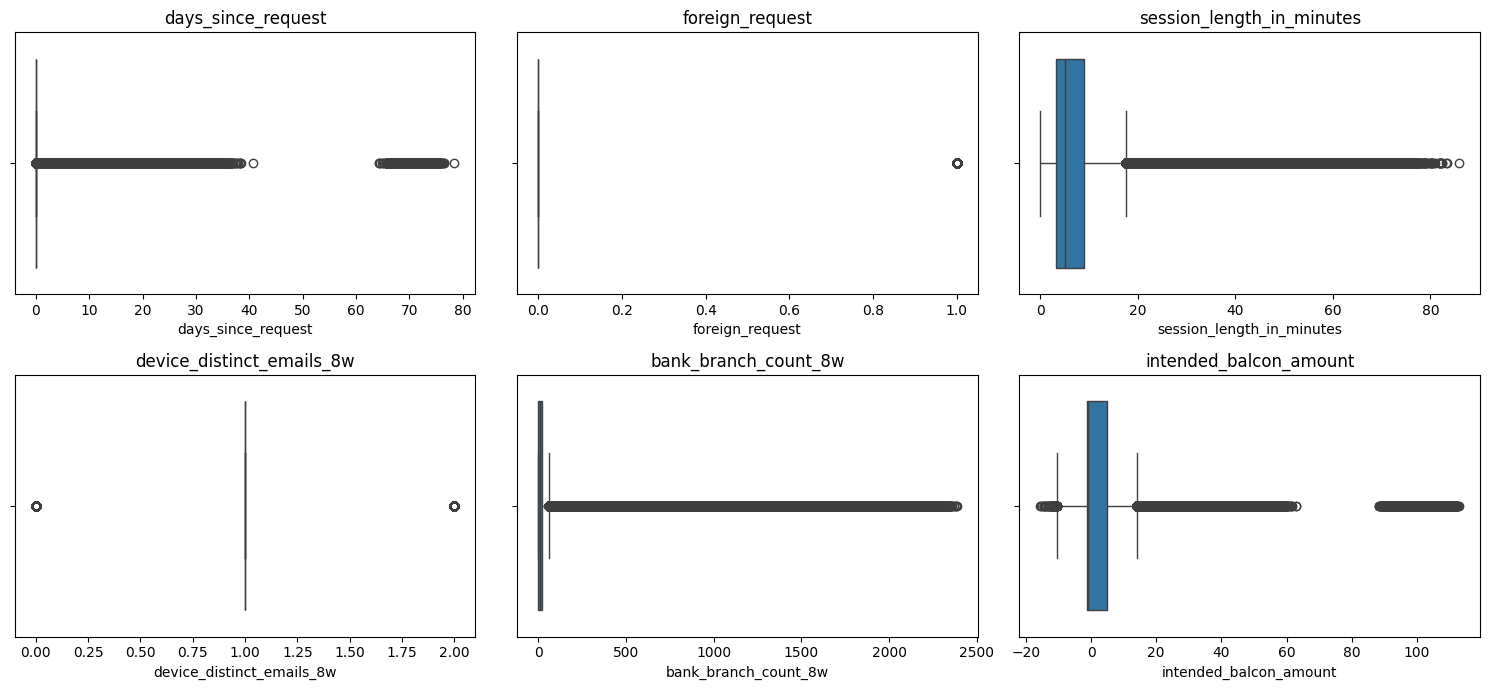

In [ ]:
# IQR outlier counts per numeric column 
def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return pd.Series({"outliers": int(mask.sum()), "outlier_pct": round(mask.mean() * 100, 2)})

outlier_tbl = df_clean[num_cols].apply(iqr_outliers).T.sort_values("outlier_pct", ascending=False)
print(outlier_tbl)

# Boxplots for the most skewed columns
top_skew = df_clean[num_cols].skew().abs().sort_values(ascending=False).head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), top_skew):
    sns.boxplot(x=df_clean[col], ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

so we know the most outlier columns via IQR and see the top 6 skewed cols

## Target & imbalance

In [86]:

counts = df[TARGET].value_counts().sort_index()          
rates  = df[TARGET].value_counts(normalize=True).sort_index()

fraud_rate     = rates.get(1, 0)
imbalance_ratio = counts.get(0, 0) / counts.get(1, 1)    

summary = pd.DataFrame({
    "count": counts,
    "percent": (rates * 100).round(3),
}).rename(index={0: "legit", 1: "fraud"})

print(summary)
print(f"\nFraud rate     : {fraud_rate:.4%}")
print(f"Imbalance ratio: {imbalance_ratio:,.1f} : 1  (legit : fraud)")


             count  percent
fraud_bool                 
legit       988971   98.897
fraud        11029    1.103

Fraud rate     : 1.1029%
Imbalance ratio: 89.7 : 1  (legit : fraud)


heavy imbalance dataset -> SMOTE? and metrics x-accuracy focus on precision and recall?

In [87]:
print("Columns with NaN:", df.isnull().sum().loc[lambda s: s > 0].to_dict() or "none")


Columns with NaN: none


In [ ]:
# Only meaningful for numeric columns; -1 is missing 
num_cols = df.select_dtypes("number").columns.drop(TARGET, errors="ignore")

neg1 = (df[num_cols] == -1).sum()
neg1 = neg1[neg1 > 0].sort_values(ascending=False)

sentinel = pd.DataFrame({
    "neg1_count": neg1,
    "neg1_pct": (neg1 / len(df) * 100).round(2),
})
print("Columns using -1 as a missing sentinel:\n", sentinel)

Columns using -1 as a missing sentinel:
                               neg1_count  neg1_pct
prev_address_months_count         712920     71.29
bank_months_count                 253635     25.36
current_address_months_count        4254      0.43
session_length_in_minutes           2015      0.20
credit_risk_score                    488      0.05
device_distinct_emails_8w            359      0.04


In [89]:
nunique = df.nunique().sort_values()
top_share = df.apply(lambda c: c.value_counts(normalize=True).iloc[0])  

quality = pd.DataFrame({
    "n_unique": nunique,
    "dominant_value_pct": (top_share * 100).round(2),
}).sort_values("n_unique")

print("Low-variance columns (candidates to drop):")
print(quality[(quality["n_unique"] <= 1) | (quality["dominant_value_pct"] >= 99)])


Low-variance columns (candidates to drop):
                    n_unique  dominant_value_pct
device_fraud_count         1               100.0
source                     2                99.3


should drop device fraud count? 

## Temporal structure & split
The month column (0–7) is the dataset's time index. The intended BAF evaluation is a temporal split to avoid leakage 

         rows  fraud_rate_pct
month                        
0      132440           1.133
1      127620           0.939
2      136979           0.875
3      150936           0.922
4      127691           1.137
5      119323           1.183
6      108168           1.341
7       96843           1.475


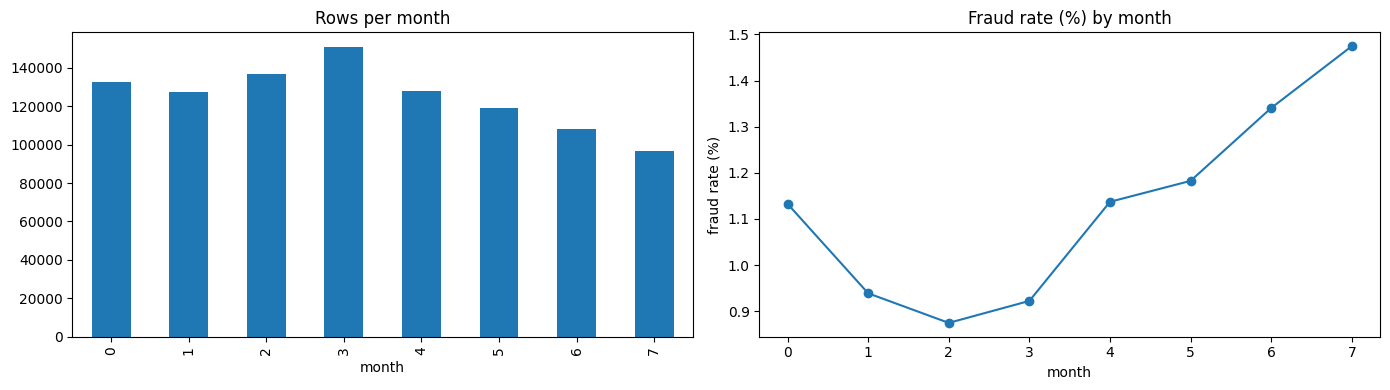

In [74]:
month_summary = df.groupby("month").agg(rows=("month", "size"), fraud_rate=(TARGET, "mean"))
month_summary["fraud_rate_pct"] = (month_summary["fraud_rate"] * 100).round(3)
print(month_summary[["rows", "fraud_rate_pct"]])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
month_summary["rows"].plot(kind="bar", ax=ax[0], title="Rows per month")
(month_summary["fraud_rate"] * 100).plot(marker="o", ax=ax[1], title="Fraud rate (%) by month")
ax[1].set_ylabel("fraud rate (%)"); ax[1].set_xlabel("month")
plt.tight_layout(); plt.show()

## Missingness (-1) analysis


In [76]:
rows = []
for col in SENTINEL_COLS:
    is_missing = df[col] == -1
    rows.append({
        "column": col,
        "missing_pct": round(is_missing.mean() * 100, 2),
        "fraud_rate_missing": round(df.loc[is_missing, TARGET].mean() * 100, 3),
        "fraud_rate_present": round(df.loc[~is_missing, TARGET].mean() * 100, 3),
    })
missing_signal = pd.DataFrame(rows)
missing_signal["lift"] = (missing_signal["fraud_rate_missing"] / missing_signal["fraud_rate_present"]).round(2)
missing_signal

,column,missing_pct,fraud_rate_missing,fraud_rate_present,lift
0,prev_address_months_count,71.29,1.421,0.312,4.55
1,bank_months_count,25.36,1.632,0.923,1.77
2,current_address_months_count,0.43,0.329,1.106,0.30
3,session_length_in_minutes,0.20,0.893,1.103,0.81
4,credit_risk_score,0.05,0.000,1.103,0.00
5,device_distinct_emails_8w,0.04,1.114,1.103,1.01


interesting the missing value of prev_address_months_ct is 4.5x rate for fraud but it's understandable 

for all columns that missing we will use median imputed / drop that row we will test for the missing value but for lift > 1 we will use like "is_[col]_available" to label that

### Should we drop source?

source
INTERNET    89.954658
TELEAPP     61.928571
Name: count, dtype: float64

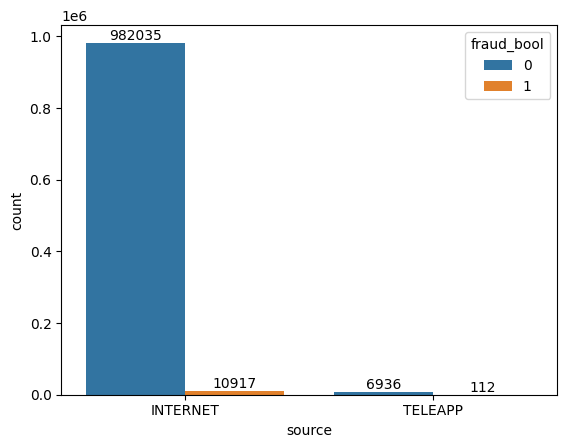

In [40]:
# plot between fraud and legit source distribution 
ax = sns.countplot(data=df, x='source', hue=TARGET, stat='count')
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='edge')
ax.bar_label(ax.containers[1], fmt='%.0f', label_type='edge')

ratio = df[df[TARGET] == 0]['source'].value_counts() / df[df[TARGET] == 1]['source'].value_counts()
ratio

No we gonna keep source 

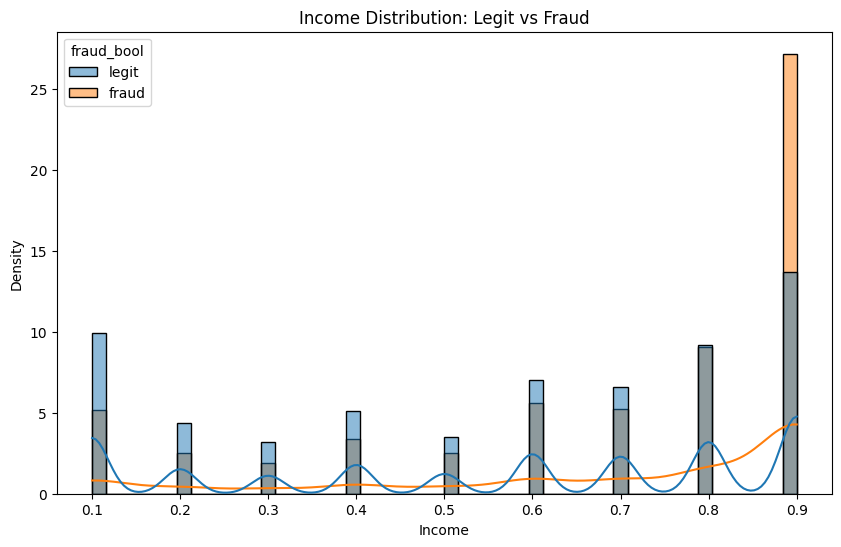

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="income",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="density",
    common_norm=False,
    bins=50,
    kde=True,
    alpha=0.5
)
plt.title("Income Distribution: Legit vs Fraud")
plt.xlabel("Income")
plt.ylabel("Density")
plt.show()
    

most of fraud transaction have high density

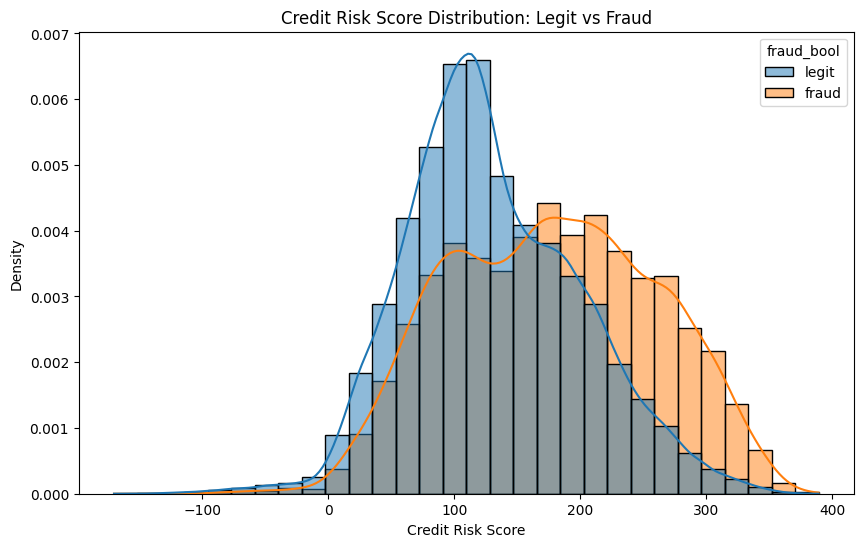

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="credit_risk_score",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="density",
    common_norm=False,
    bins=30,
    kde=True,
    alpha=0.5
)
plt.title("Credit Risk Score Distribution: Legit vs Fraud")
plt.xlabel("Credit Risk Score")
plt.ylabel("Density")
plt.show()


customer_age
10    282.608108
20    203.029046
30    119.290846
40     82.001391
50     49.036720
60     29.261097
70     23.779468
80     19.265625
90     18.000000
Name: count, dtype: float64

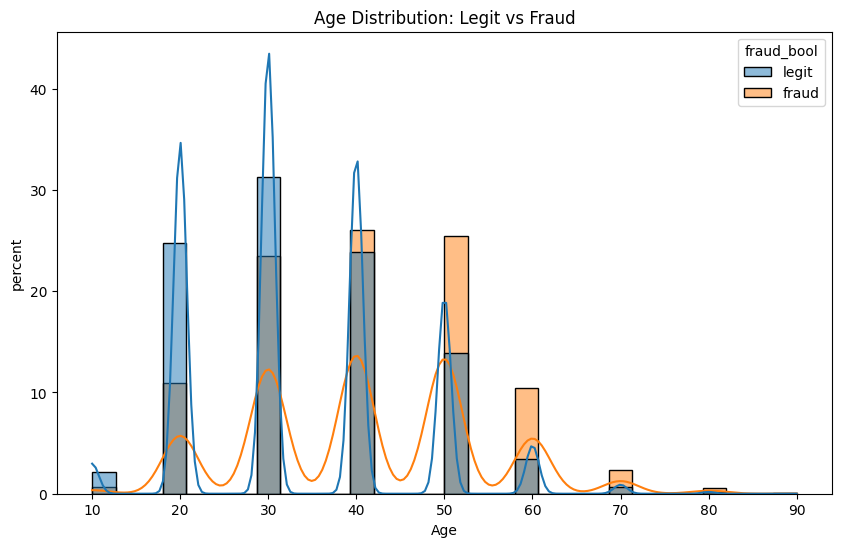

In [62]:
#distribution of fraud and legit customer age distribution
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x="customer_age",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="percent",
    common_norm=False,
    bins=30,
    kde=True,
    alpha=0.5,

)
plt.title("Age Distribution: Legit vs Fraud")
plt.xlabel("Age")
plt.ylabel("percent")

ratio = df[df[TARGET] == 0]['customer_age'].value_counts() / df[df[TARGET] == 1]['customer_age'].value_counts()
ratio

                        total  fraud   legit  fraud_rate  legit_to_fraud_ratio
name_email_similarity                                                         
0.0-0.1                 90360   1872   88488    0.020717             47.269231
0.1-0.2                130685   2342  128343    0.017921             54.800598
0.2-0.3                105271   1399  103872    0.013290             74.247320
0.3-0.4                 81944    805   81139    0.009824            100.793789
0.4-0.5                100800    705  100095    0.006994            141.978723
0.5-0.6                101219    702  100517    0.006935            143.186610
0.6-0.7                 83226    618   82608    0.007426            133.669903
0.7-0.8                101579   1005  100574    0.009894            100.073632
0.8-0.9                133087   1104  131983    0.008295            119.549819
0.9-1.0                 71829    477   71352    0.006641            149.584906


/var/folders/0w/dg96nhvx2qdd7h5pk8ft6mhh0000gn/T/ipykernel_84456/1488042508.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


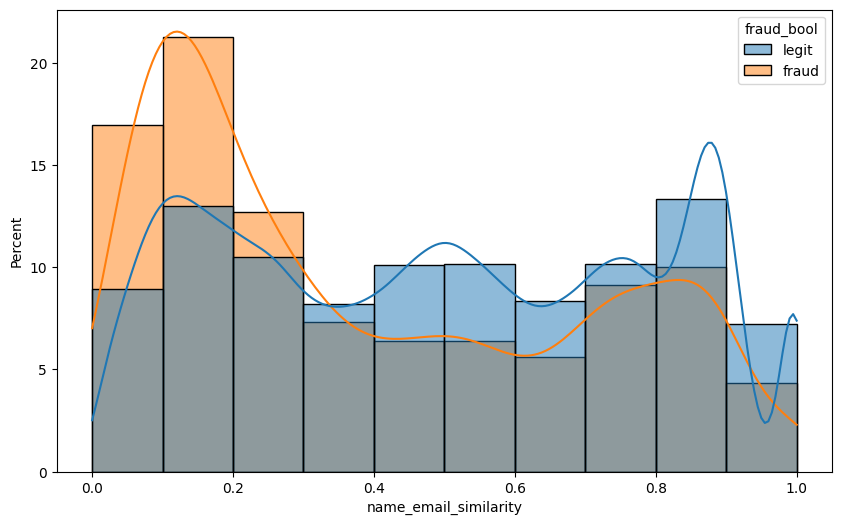

In [60]:
# plot distribution of fraud vs legit on name-email-similarity
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="name_email_similarity",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="percent",
    common_norm=False,
    bins=10,
    kde=True,
    alpha=0.5,

)
bins = np.linspace(0, 1, 11)
labels = [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)]

ratio_df = (
    df.groupby(
        pd.cut(
            df["name_email_similarity"],
            bins=bins,
            labels=labels,
            include_lowest=True,
        )
    )[TARGET]
    .agg(total="size", fraud="sum")
    .assign(
        legit=lambda x: x["total"] - x["fraud"],
        fraud_rate=lambda x: x["fraud"] / x["total"],
        legit_to_fraud_ratio=lambda x: x["legit"] / x["fraud"].replace(0, np.nan),
    )
)

print(ratio_df)



payment_type
AA    188.332111
AB     87.883185
AC     58.888572
AD     91.408243
AE    288.000000
Name: count, dtype: float64

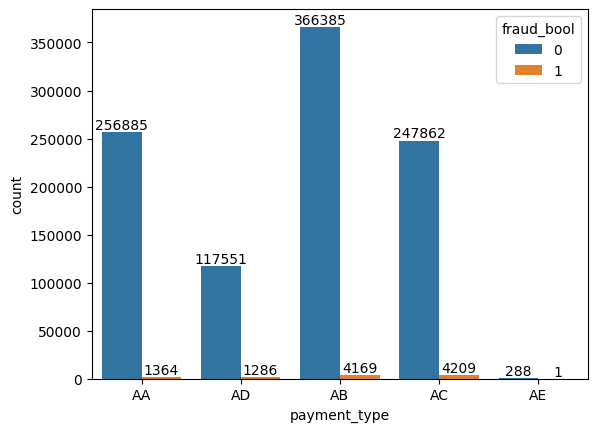

In [ ]:
# plot between fraud and legit source distribution 
ax = sns.countplot(data=df, x='payment_type', hue=TARGET, stat='count')
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='edge')
ax.bar_label(ax.containers[1], fmt='%.0f', label_type='edge')

ratio = df[df[TARGET] == 0]['payment_type'].value_counts() / df[df[TARGET] == 1]['payment_type'].value_counts()
ratio
# useless????

## Quantitative feature ranking


In [ ]:
# Numeric: direction-agnostic single-feature AUC + KS separation (-1 masked)
y = df[TARGET].values
rows = []
for col in num_cols:
    x = df_clean[col]
    valid = x.notna()
    xv, yv = x[valid], y[valid]
    auc = roc_auc_score(yv, xv) # direction-agnostic AUC
    ks = ks_2samp(xv[yv == 1], xv[yv == 0]).statistic #watch distribution differences
    rows.append({"feature": col, "auc": round(max(auc, 1 - auc), 4),
                 "ks": round(ks, 4), "coverage_pct": round(valid.mean() * 100, 1)})
numeric_rank = pd.DataFrame(rows).sort_values("auc", ascending=False).reset_index(drop=True)
numeric_rank

,feature,auc,ks,coverage_pct
0,credit_risk_score,0.6662,0.2636,100.0
1,customer_age,0.6557,0.2301,100.0
2,proposed_credit_limit,0.6385,0.2232,100.0
3,income,0.6356,0.2154,100.0
4,current_address_months_count,0.6333,0.2613,99.6
5,date_of_birth_distinct_emails_4w,0.6259,0.1776,100.0
6,keep_alive_session,0.6190,0.2379,100.0
7,name_email_similarity,0.6031,0.1856,100.0
8,bank_branch_count_8w,0.5888,0.1665,100.0
9,prev_address_months_count,0.5859,0.1518,28.7


ooh nice we can see top feat that we should use 

In [90]:
# Fraud rate per category 
for col in ["payment_type", "housing_status", "employment_status", "device_os"]:
    fr = (df.groupby(col)[TARGET].mean() * 100).round(3).sort_values(ascending=False)
    print(f"\nFraud rate (%) by {col}:\n{fr}")


Fraud rate (%) by payment_type:
payment_type
AC    1.670
AB    1.125
AD    1.082
AA    0.528
AE    0.346
Name: fraud_bool, dtype: float64

Fraud rate (%) by housing_status:
housing_status
BA    3.747
BD    0.864
BC    0.615
BB    0.601
BF    0.419
BG    0.397
BE    0.344
Name: fraud_bool, dtype: float64

Fraud rate (%) by employment_status:
employment_status
CC    2.468
CG    1.545
CA    1.219
CB    0.689
CD    0.377
CE    0.234
CF    0.193
Name: fraud_bool, dtype: float64

Fraud rate (%) by device_os:
device_os
windows      2.469
macintosh    1.397
x11          1.121
other        0.576
linux        0.515
Name: fraud_bool, dtype: float64


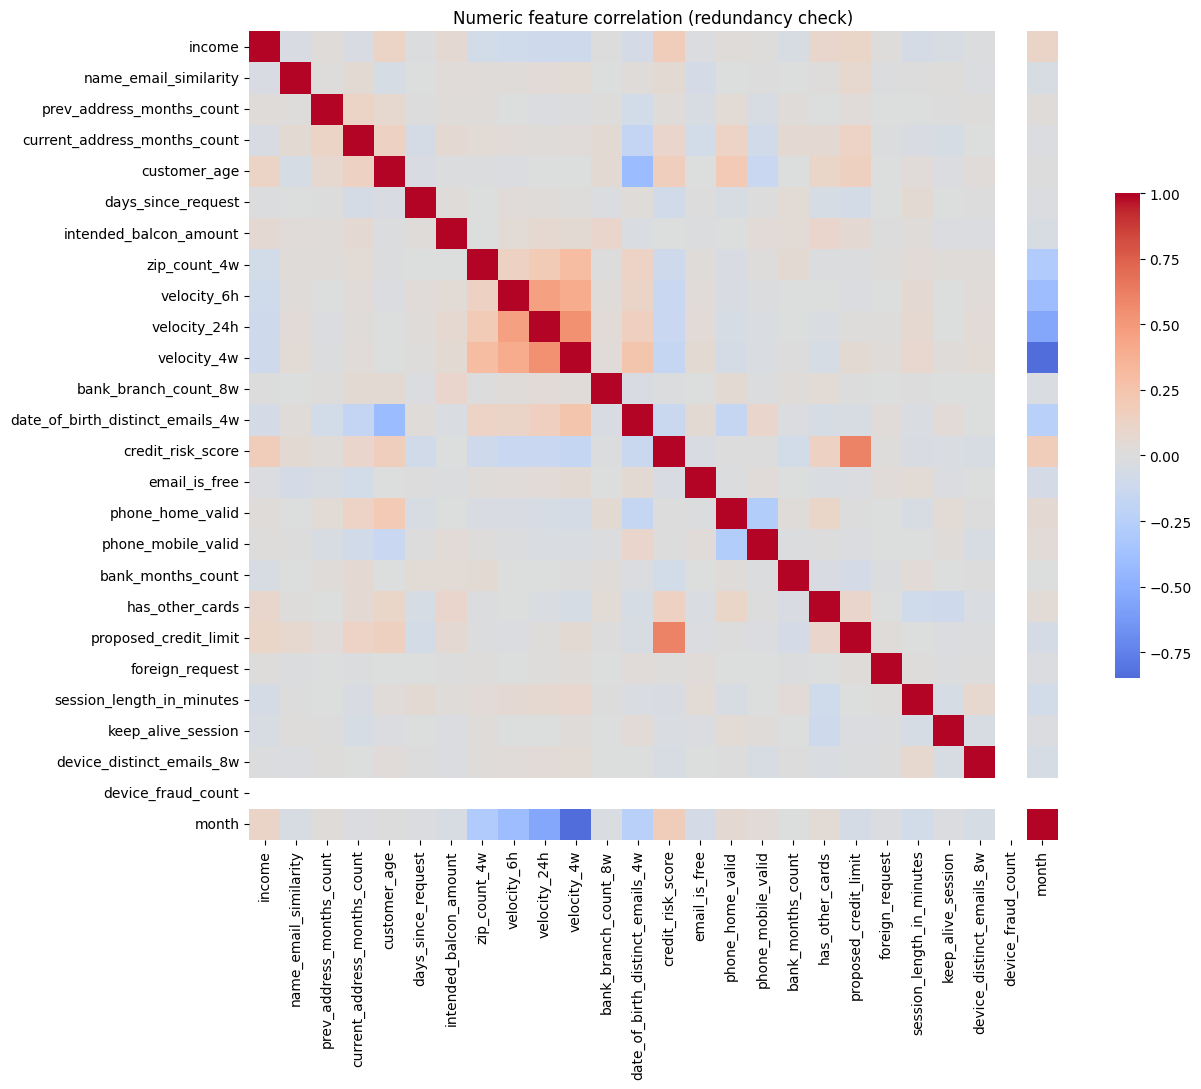

Highly correlated pairs (|r| > 0.8):
 velocity_4w  month   -0.8481
dtype: float64


In [ ]:
# Correlation
plt.figure(figsize=(14, 11))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
plt.title("Numeric feature correlation (redundancy check)")
plt.tight_layout(); plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().loc[lambda s: s.abs() > 0.8].sort_values(key=abs, ascending=False)
print("Highly correlated pairs (|r| > 0.8):\n", pairs)

HMmmmm what we got after doing this????

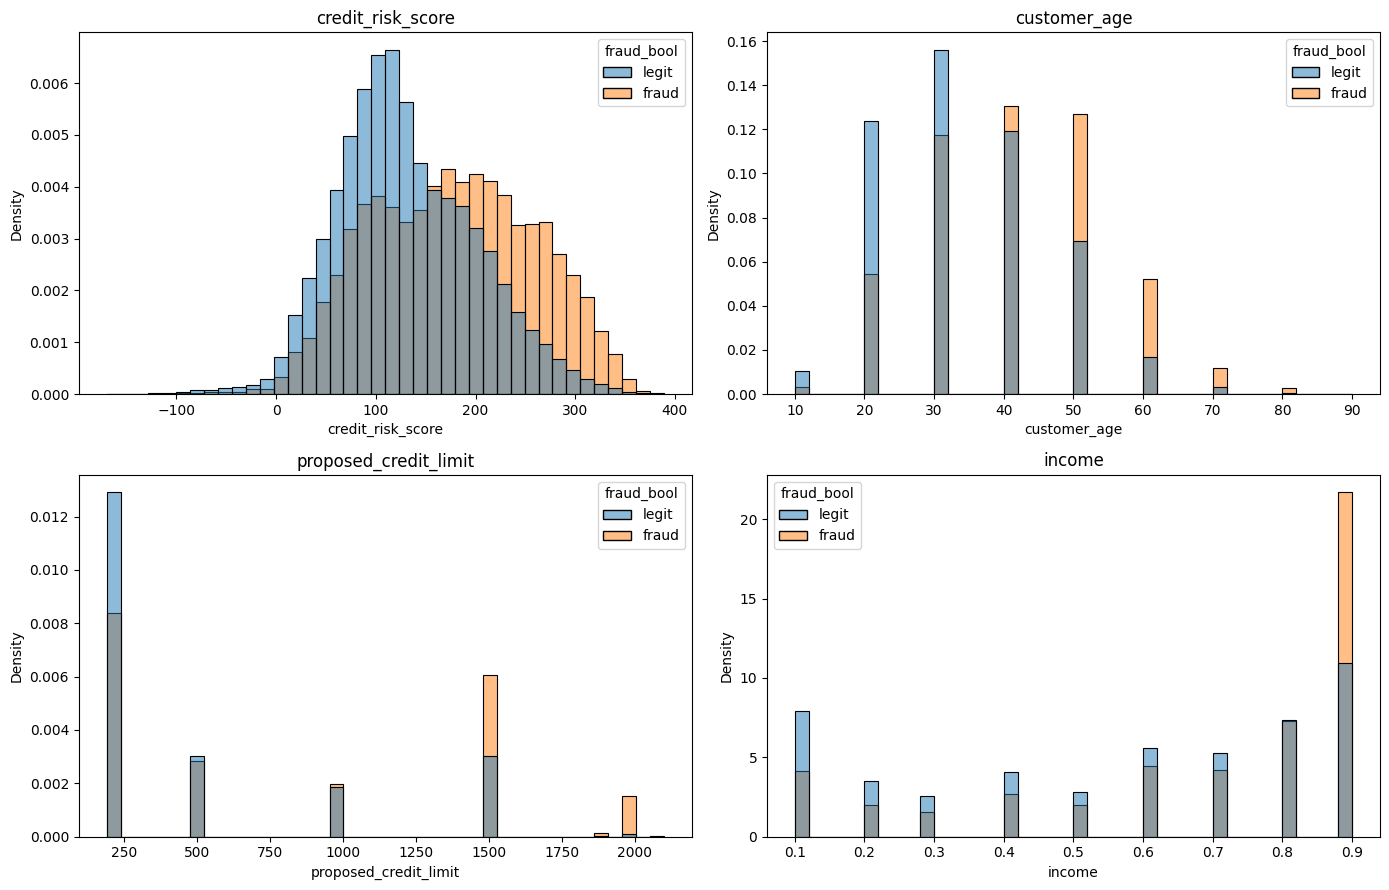

In [83]:
# Class-conditional distributions for the top-ranked numeric features
top_feats = numeric_rank.head(4)["feature"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), top_feats):
    sns.histplot(data=df_clean, x=col, hue=df[TARGET].map({0: "legit", 1: "fraud"}),
                 stat="density", common_norm=False, bins=40, alpha=0.5, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()